In [1]:
import torch
from torch.utils.data import DataLoader

from shapenet_dataset import ShapeNetDataset
from visualize import plot_pointclouds, visualize_reconstructions

# autoreload py
%load_ext autoreload
%autoreload 2

# Data Loading & Visualization

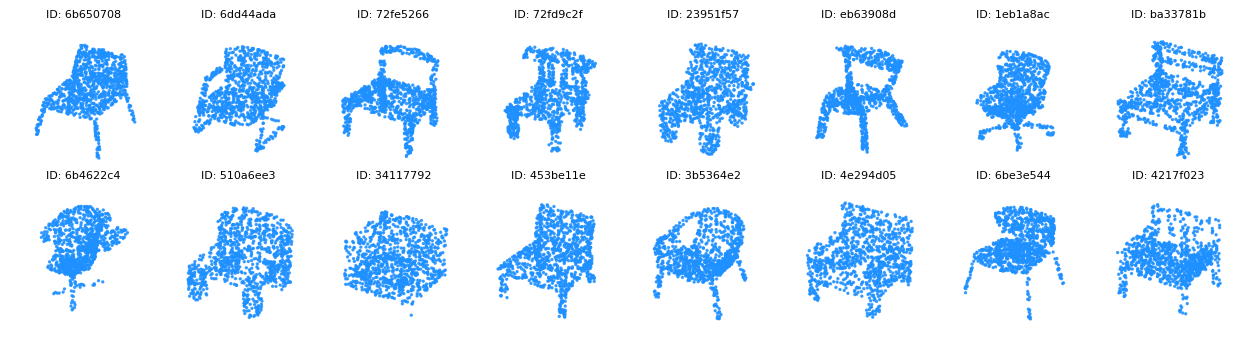

In [2]:
# raw mesh loader was very slow, precompute pointcloud as .npy instead
# dataset = ShapeNetDataset(data_dir='/ist/ist-share/scads/ploy/scene2/big_file/shapenet/shapenet/', object_class='03001627', num_points=1024)

dataset = ShapeNetDataset(data_dir='./sampled_poincloud/', object_class='03001627')
dataloader = DataLoader(dataset, batch_size=16, shuffle=True)

# plot 3d scatter of first batch
for batch in dataloader:
    pcs = batch['points']  # shape (B, N, 3)
    ids = batch['object_id']
    pc_list = list(zip(ids, pcs))
    plot_pointclouds(pc_list, n_cols=8)
    break

## Experiment Flow

- Define model and loss directly in this notebook for each experiment.
- Use `run_training(...)` from `experiment_runner.py` for training loop, checkpoints, metrics, tqdm, and optional wandb.

## Experiment List
- Baseline 1: Base model (no seed), Loss: Chamfer.
- Baseline 2: Base model (no seed), Loss: Chamfer + Repulsion.

## Setting up

In [3]:
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Subset
from model.base_model import PointCloudAE
from pytorch3d.loss import chamfer_distance
import numpy as np

from experiment_runner import ExperimentConfig, run_training

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

# Shared configs for all runs
z_dim = 1024
batch_size = 16
num_epochs = 100
lr = 1e-3
val_split = 0.1
seed = 42

# Notebook-safe default: multiprocessing DataLoader workers can trigger
# "can only test a child process" cleanup errors in Jupyter.
num_workers = 0

torch.manual_seed(seed)
np.random.seed(seed)

num_points = dataset[0]["points"].shape[0]
all_indices = np.arange(len(dataset))
train_idx, val_idx = train_test_split(
    all_indices, test_size=val_split, random_state=seed, shuffle=True
)
train_set = Subset(dataset, train_idx)
val_set = Subset(dataset, val_idx)

train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=num_workers,
    pin_memory=(device == "cuda"),
)
val_loader = DataLoader(
    val_set,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=(device == "cuda"),
)

/ist-nas/users/pratchp/conda_envs/pyt3d/lib/python3.10/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.3)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


device: cuda


FPS step 1/3:   0%|          | 0/678 [00:00<?, ?it/s]

FPS step 2/3:   0%|          | 0/678 [00:00<?, ?it/s]

FPS step 3/3:   0%|          | 0/678 [00:00<?, ?it/s]

Selected val_set local indices: [60, 439, 310, 592]
Selected dataset indices: [3289, 1670, 4959, 3904]
Selected object_ids: ['7a427785ad85f0c771c3cf047830ec1f', '48f0c9b02587b5a8ea0588dd0d874b1e', 'bb4f5cd713a817727d4f8900c5174db0', '920af478601258e24762da3a3017ade']


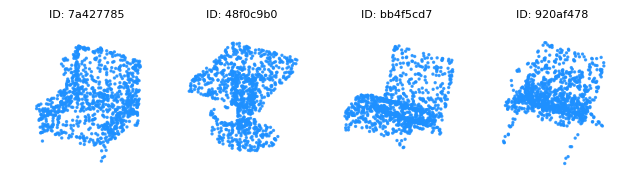

Created diverse_val_loader with 4 FPS-selected chairs.


In [6]:
# Select 4 maximally diverse validation chairs using greedy farthest-point sampling
from tqdm.auto import tqdm

def select_diverse_chairs_fps(
    subset,
    n_select=4,
    seed=42,
    compute_device=None,
    show_progress=True,
    batch_reduction="mean",
    point_reduction="mean",
):
    if compute_device is None:
        compute_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    else:
        compute_device = torch.device(compute_device)

    n_items = len(subset)
    if n_items < n_select:
        raise ValueError(f"Need at least {n_select} samples, but only found {n_items}")

    # Cache points and ids once to avoid repeated dataset indexing work.
    points_cpu = []
    object_ids = []
    for i in range(n_items):
        sample = subset[i]
        points_cpu.append(sample["points"].float().cpu())
        object_ids.append(str(sample.get("object_id", i)))

    rng = np.random.default_rng(seed)
    first_idx = int(rng.integers(0, n_items))
    selected = [first_idx]
    selected_set = {first_idx}

    min_dist_to_selected = torch.full((n_items,), float("inf"), dtype=torch.float32)

    for _ in range(1, n_select):
        last_idx = selected[-1]
        last_pc = points_cpu[last_idx].to(compute_device).unsqueeze(0)

        iterator = range(n_items)
        if show_progress:
            iterator = tqdm(iterator, leave=False, desc=f"FPS step {len(selected)}/{n_select - 1}")

        with torch.no_grad():
            for i in iterator:
                if i in selected_set:
                    continue
                cand_pc = points_cpu[i].to(compute_device).unsqueeze(0)
                d = chamfer_distance(
                    last_pc,
                    cand_pc,
                    batch_reduction=batch_reduction,
                    point_reduction=point_reduction,
                )[0].item()
                if d < float(min_dist_to_selected[i]):
                    min_dist_to_selected[i] = d

        min_dist_to_selected[list(selected_set)] = -float("inf")
        next_idx = int(torch.argmax(min_dist_to_selected).item())
        selected.append(next_idx)
        selected_set.add(next_idx)

    return selected, object_ids, points_cpu

# Run FPS on the validation subset
diverse_local_idx, val_object_ids, val_points_cpu = select_diverse_chairs_fps(
    subset=val_set,
    n_select=4,
    seed=seed,
    compute_device=device,
    show_progress=True,
)

diverse_dataset_idx = [int(val_idx[i]) for i in diverse_local_idx]
diverse_ids = [val_object_ids[i] for i in diverse_local_idx]

print("Selected val_set local indices:", diverse_local_idx)
print("Selected dataset indices:", diverse_dataset_idx)
print("Selected object_ids:", diverse_ids)

# Visual sanity check: these are the 4 anchors for hard interpolation.
diverse_pc_list = [(diverse_ids[i], val_points_cpu[diverse_local_idx[i]]) for i in range(4)]
plot_pointclouds(diverse_pc_list, n_cols=4)

# Loader where these 4 anchors come first (use this in make_interpolation_figure/visualize_interpolations).
diverse_val_set = Subset(val_set, diverse_local_idx)
diverse_val_loader = DataLoader(
    diverse_val_set,
    batch_size=4,
    shuffle=False,
    num_workers=0,
    pin_memory=(device == "cuda"),
)
print("Created diverse_val_loader with 4 FPS-selected chairs.")

## Baseline 1

In [4]:
import wandb
# wandb.login(key="")

In [ ]:
# 1) Baseline experiment: Chamfer Distance only
model_cd = PointCloudAE(z_dim=z_dim, num_points=num_points)
optimizer_cd = torch.optim.Adam(model_cd.parameters(), lr=lr)
loss_fn_cd = lambda recon, points: chamfer_distance(
    recon.float(),
    points.float(),
    batch_reduction="mean",
    point_reduction="mean",
)[0]

cfg_cd = ExperimentConfig(
    name="baseline_cd",
    num_epochs=num_epochs,
    seed=seed,
    use_amp=True,
    save_every=10,
    run_root="/ist-nas/ist-share/vision/pratchp/shapevae_weights/",
    epoch_log_every=10,
)

run_dir_cd, summary_cd = run_training(
    config=cfg_cd,
    model=model_cd,
    optimizer=optimizer_cd,
    loss_fn=loss_fn_cd,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
)
print("Baseline CD run dir:", run_dir_cd)
print("Baseline CD summary:", summary_cd)

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/pratch/.netrc.
wandb: Currently logged in as: alephnir (alephnir-vistec) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


train:baseline_cd:   0%|          | 0/42500 [00:00<?, ?it/s]

[baseline_cd] epoch 10/100 train 0.004932 val 0.005057 best 0.005057
[baseline_cd] epoch 20/100 train 0.004080 val 0.004424 best 0.004402
[baseline_cd] epoch 30/100 train 0.003676 val 0.004097 best 0.004097
[baseline_cd] epoch 40/100 train 0.003392 val 0.003960 best 0.003947
[baseline_cd] epoch 50/100 train 0.003202 val 0.003931 best 0.003924
[baseline_cd] epoch 60/100 train 0.003060 val 0.003976 best 0.003872
[baseline_cd] epoch 70/100 train 0.002983 val 0.003863 best 0.003863
[baseline_cd] epoch 80/100 train 0.002905 val 0.003878 best 0.003863
[baseline_cd] epoch 90/100 train 0.002849 val 0.003897 best 0.003863
[baseline_cd] epoch 100/100 train 0.002824 val 0.003937 best 0.003863


epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▆▇▇████
train/loss,█▆▅▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/best,█▄▄▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/loss,█▄▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
best_epoch,70
best_val,0.00386
epoch,100
train/loss,0.00282
val/best,0.00386
val/loss,0.00394


Baseline CD run dir: /ist-nas/ist-share/vision/pratchp/shapevae_weights/20260426-180458_pratch_baseline_cd
Baseline CD summary: {'best_val': 0.0038634517262581478, 'best_epoch': 70}


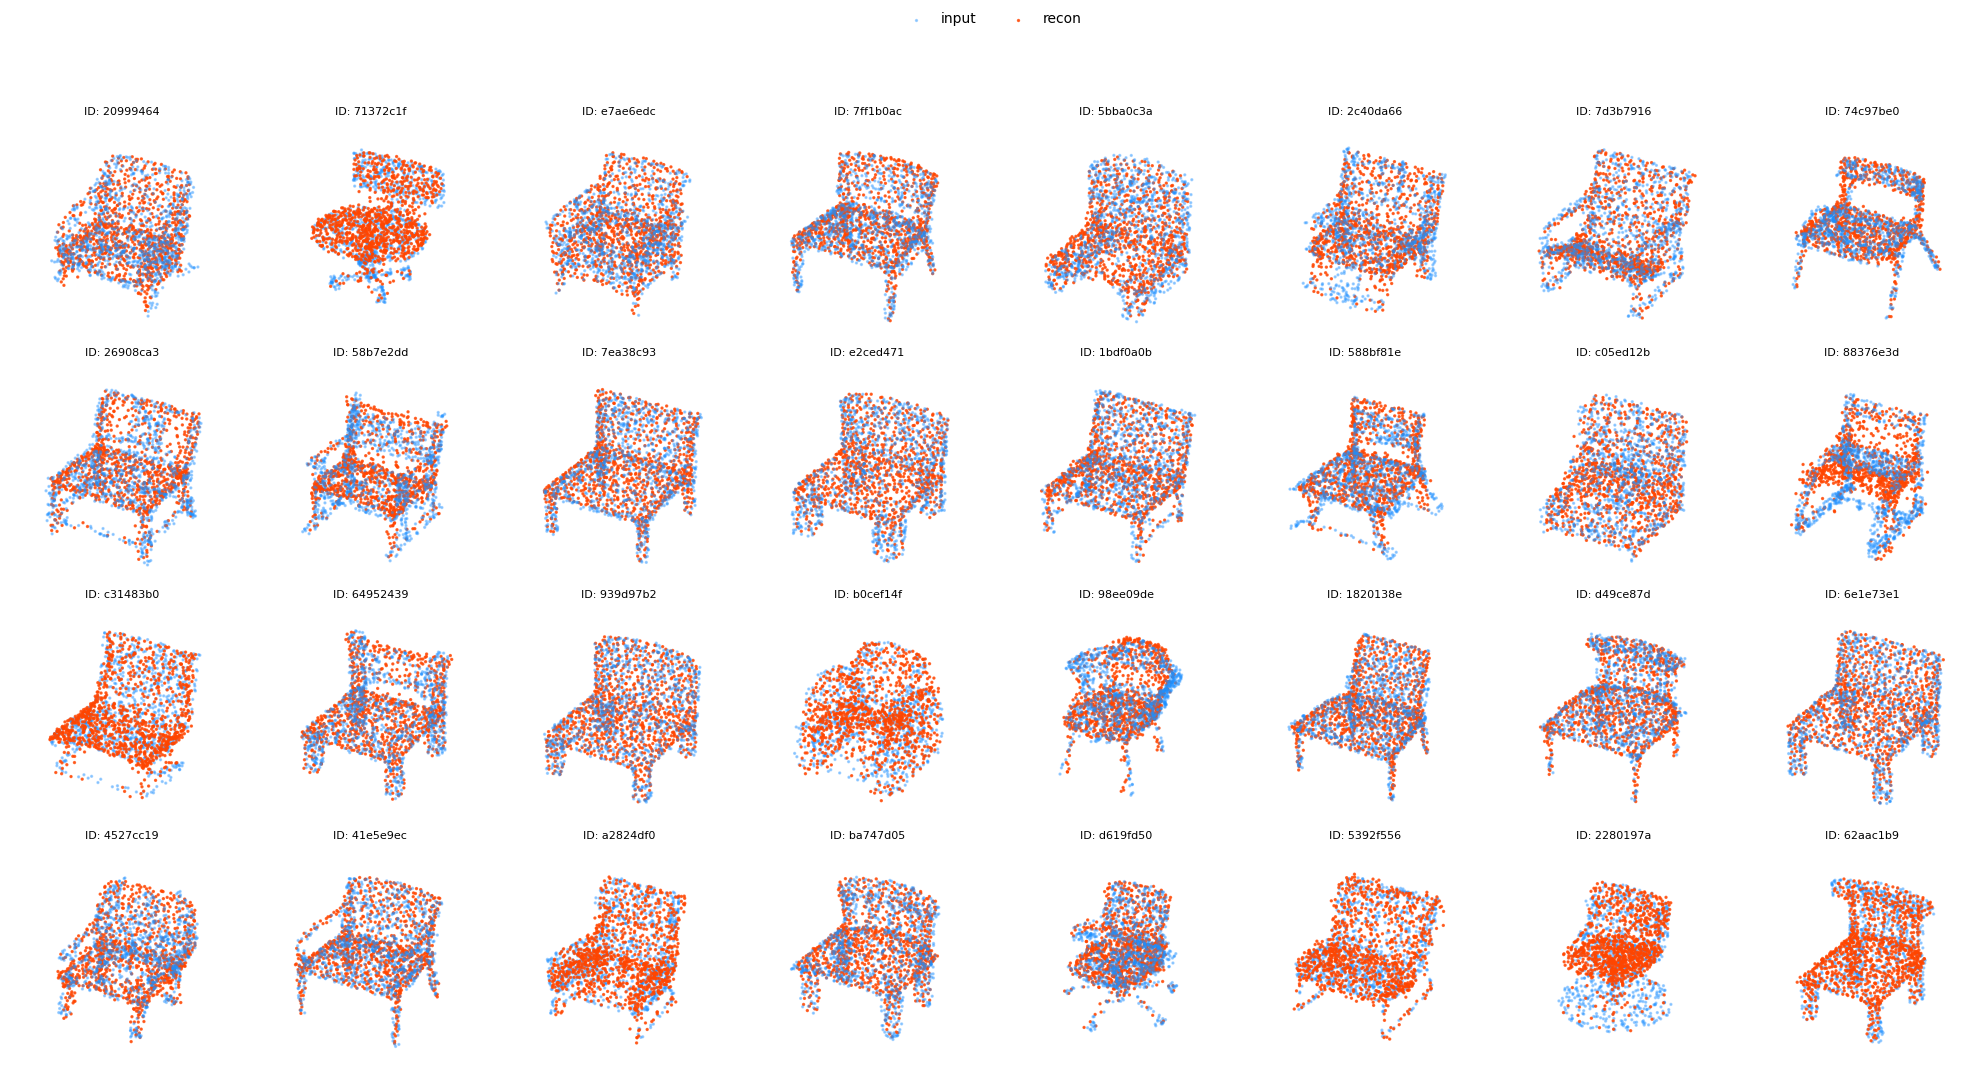

In [11]:
# Visualize baseline reconstructions across N validation batches
visualize_reconstructions(
    model=model_cd,
    loader=val_loader,
    device=device,
    num_batches=2,
    n_cols=8,
)

In [ ]:
# 2) Baseline skeleton: Chamfer + Repulsion
# Keep model/optimizer definitions explicit; only loss changes.
model_rep = PointCloudAE(z_dim=z_dim, num_points=num_points)
optimizer_rep = torch.optim.Adam(model_rep.parameters(), lr=lr)

def repulsion_loss_placeholder(_pred_points):
    # TODO: implement your repulsion loss here.
    raise NotImplementedError("Implement repulsion loss before running this experiment")

def loss_fn_cd_plus_repulsion(recon, points):
    cd = chamfer_distance(
        recon,
        points,
        batch_reduction="mean",
        point_reduction="mean",
    )[0]
    rep = repulsion_loss_placeholder(recon)
    return cd + 0.1 * rep

cfg_cd_rep = ExperimentConfig(
    name="baseline_cd_plus_repulsion_skeleton",
    num_epochs=num_epochs,
    seed=seed,
    use_amp=True,
    save_every=10,
    run_root="runs",
)

print("Repulsion skeleton ready: implement repulsion_loss_placeholder, then uncomment run.")
# run_dir_rep, summary_rep = run_training(
#     config=cfg_cd_rep,
#     model=model_rep,
#     optimizer=optimizer_rep,
#     loss_fn=loss_fn_cd_plus_repulsion,
#     train_loader=train_loader,
#     val_loader=val_loader,
#     device=device,
# )